<style>
.jp-RenderedHTMLCommon table,
.rendered_html table {
  margin-left: 0 !important;
  margin-right: auto !important;
}
.jp-RenderedHTMLCommon th,
.jp-RenderedHTMLCommon td,
.rendered_html th,
.rendered_html td {
  text-align: left !important;
}
</style>

# 07 - Day 1 Mini EDA Project

<div style="background:#F7FAFC; border:1px solid #D9E2EC; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/goal.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Notebook Header</b><br>
<b>Day:</b> Day 1 - EDA and preprocessing foundations<br>
<b>Difficulty:</b> Beginner project<br>
<b>Estimated time:</b> 60-90 minutes<br>
<b>Prerequisites:</b> Notebooks 01 to 06 completed<br>
<b>Output:</b> You will create a short EDA report using cleaned customer data.<br>
<b>Next day:</b> Introduction to learning from data and predicting numbers
</div>

<details>
<summary><b>Instructor talk track</b></summary>

This notebook is the Day 1 integration lab. Students should not learn many new commands here. They should practice combining previous skills into a coherent analysis story: question, evidence, observation, and recommendation.

</details>

## <img src="../../../assets/icons/map.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Project Learning Map

By the end of this notebook, you should be able to:

- Load a cleaned dataset
- Frame simple business questions
- Inspect data quality
- Summarize numeric and categorical columns
- Create charts for EDA
- Write observations in plain English
- Prepare a short EDA report

## <img src="../../../assets/icons/loop.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Signature Learning Loop

```text
QUESTION -> DATA -> CODE -> EVIDENCE -> DECISION
```


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Project Scenario

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Scenario</b><br>
A small retail business wants to understand customer activity using basic data analysis.
</div>

The business wants simple answers:

- Which membership group spends more on average?
- Which city has more customers?
- How much do customers usually spend?
- Are more visits associated with higher spending?
- What should the business look at next?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Import libraries and load cleaned customer activity data.
</div>


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

current = Path.cwd().resolve()
project_root = current

for candidate in [current, *current.parents]:
    if candidate.name == "applied_ds_ml":
        project_root = candidate
        break

data_path = project_root / "data" / "customer_activity_clean.csv"

if not data_path.exists():
    raise FileNotFoundError("Run Notebook 03 first so data/customer_activity_clean.csv is created.")

customers = pd.read_csv(data_path)
customers


,customer_id,name,city,membership,monthly_spend,visits_per_month,signup_month
0,101,Asha,Mumbai,Gold,1200.0,4.0,Jan
1,102,Ravi,Delhi,Silver,850.0,3.0,Feb
2,103,Meera,Chennai,Gold,1450.0,5.0,Feb
3,104,John,Mumbai,Bronze,700.0,2.0,Mar
4,105,Fatima,Unknown,Silver,1025.0,6.0,Apr
5,106,Chen,Chennai,Gold,1600.0,5.0,Apr
6,107,Sara,Delhi,Unknown,950.0,4.0,May
7,108,Vikram,Mumbai,Bronze,1025.0,1.0,Jun
8,109,Nina,Delhi,Silver,1100.0,4.0,Jun


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 1: Frame Analysis Questions

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
EDA should start with questions. Questions guide what we inspect, calculate, and visualize.
</div>

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a list of analysis questions for this project.
</div>


In [2]:
analysis_questions = [
    "How many customers are in the dataset?",
    "Which city has the most customers?",
    "Which membership type has the highest average monthly spend?",
    "What is a typical monthly spend?",
    "Do visits per month and monthly spend move together?",
]

for question in analysis_questions:
    print("-", question)


- How many customers are in the dataset?
- Which city has the most customers?
- Which membership type has the highest average monthly spend?
- What is a typical monthly spend?
- Do visits per month and monthly spend move together?


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 2: Basic Dataset Inspection

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
Before summarizing data, confirm the dataset structure and quality.
</div>

We will check:

- Rows and columns
- Column names
- Missing values
- Duplicate rows

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Run basic inspection checks.
</div>


In [3]:
print("Rows and columns:", customers.shape)
print("Column names:", list(customers.columns))
print("Duplicate rows:", customers.duplicated().sum())

print("\nMissing values:")
print(customers.isna().sum())


Rows and columns: (9, 7)
Column names: ['customer_id', 'name', 'city', 'membership', 'monthly_spend', 'visits_per_month', 'signup_month']
Duplicate rows: 0

Missing values:
customer_id         0
name                0
city                0
membership          0
monthly_spend       0
visits_per_month    0
signup_month        0
dtype: int64


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Observation Prompt: Dataset Inspection

Write observations in this format:

- The dataset has ____ rows and ____ columns.
- The dataset has ____ duplicate rows.
- The missing value check shows ____.


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 3: Customer Count by City

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Question</b><br>
Which city has the most customers?
</div>

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a city count table and bar chart.
</div>


city
Mumbai     3
Delhi      3
Chennai    2
Unknown    1
Name: count, dtype: int64

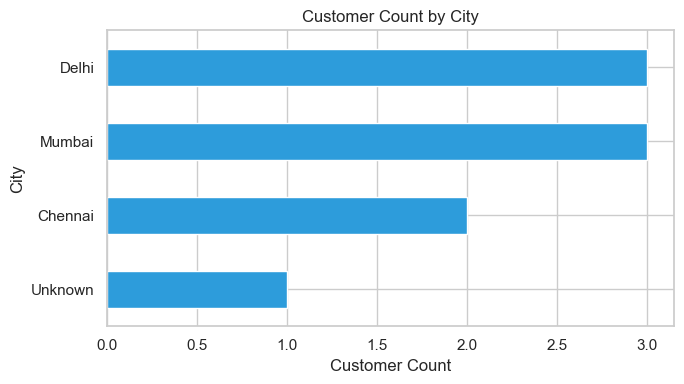

In [4]:
city_counts = customers["city"].value_counts()
display(city_counts)

plt.figure(figsize=(7, 4))
city_counts.sort_values().plot(kind="barh", color="#2D9CDB")
plt.title("Customer Count by City")
plt.xlabel("Customer Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Observation Prompt: City Count

- The city with the most customers is ____.
- The city with the fewest customers is ____.
- This may help the business understand where its current customer base is concentrated.


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 4: Spend by Membership

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Question</b><br>
Which membership type has the highest average monthly spend?
</div>

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Calculate and visualize average spend by membership.
</div>


membership
Gold       1416.67
Silver      991.67
Unknown     950.00
Bronze      862.50
Name: monthly_spend, dtype: float64

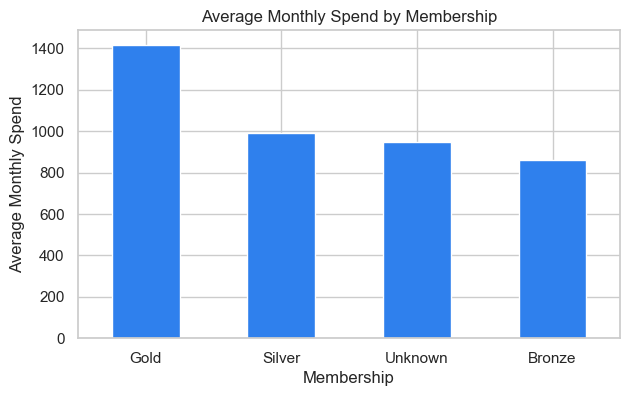

In [5]:
membership_spend = customers.groupby("membership")["monthly_spend"].mean().sort_values(ascending=False)
display(membership_spend.round(2))

plt.figure(figsize=(7, 4))
membership_spend.plot(kind="bar", color="#2F80ED")
plt.title("Average Monthly Spend by Membership")
plt.xlabel("Membership")
plt.ylabel("Average Monthly Spend")
plt.xticks(rotation=0)
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Observation Prompt: Membership Spend

- The membership type with the highest average monthly spend is ____.
- The membership type with the lowest average monthly spend is ____.
- This suggests the business may want to study what makes higher-spending groups different.


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 5: Typical Monthly Spend

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Question</b><br>
What is a typical monthly spend?
</div>

We will compare:

- Mean
- Median
- Standard deviation
- Minimum and maximum

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a spending summary table.
</div>


In [6]:
spend_summary = pd.DataFrame({
    "statistic": ["mean", "median", "standard deviation", "minimum", "maximum"],
    "value": [
        customers["monthly_spend"].mean(),
        customers["monthly_spend"].median(),
        customers["monthly_spend"].std(),
        customers["monthly_spend"].min(),
        customers["monthly_spend"].max(),
    ]
})

spend_summary["value"] = spend_summary["value"].round(2)
spend_summary


,statistic,value
0,mean,1100.00
1,median,1025.00
2,standard deviation,282.57
3,minimum,700.00
4,maximum,1600.00


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Observation Prompt: Typical Spend

- The average monthly spend is ____.
- The median monthly spend is ____.
- The standard deviation is ____.
- This means customer spending is ____.


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 6: Monthly Spend Distribution

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Question</b><br>
Where do monthly spend values concentrate?
</div>

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a histogram for monthly spend.
</div>


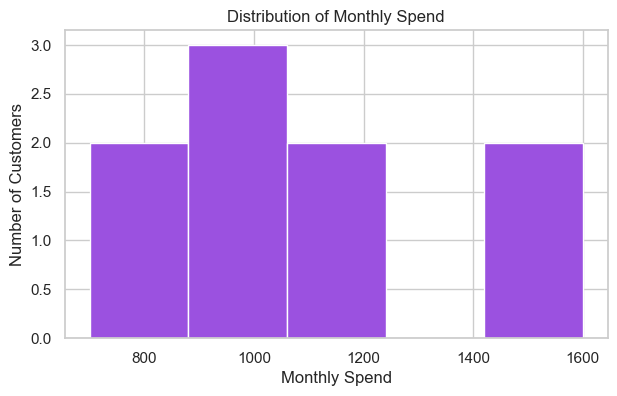

In [7]:
plt.figure(figsize=(7, 4))
plt.hist(customers["monthly_spend"], bins=5, color="#9B51E0", edgecolor="white")
plt.title("Distribution of Monthly Spend")
plt.xlabel("Monthly Spend")
plt.ylabel("Number of Customers")
plt.show()


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 7: Visits and Spending

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Question</b><br>
Do visits per month and monthly spend move together?
</div>

We will use:

- Correlation table
- Scatter plot

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Calculate correlation and create a scatter plot.
</div>


,visits_per_month,monthly_spend
visits_per_month,1.000,0.559
monthly_spend,0.559,1.000


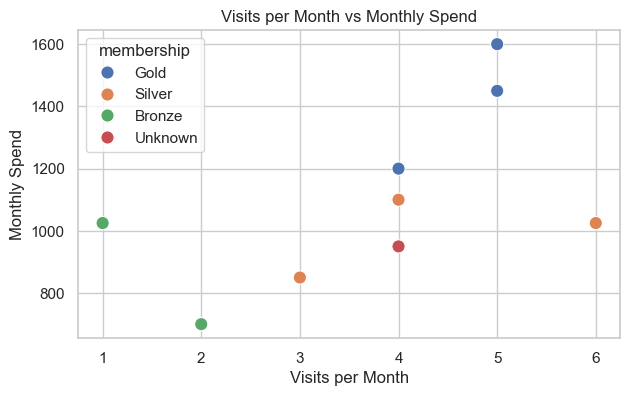

In [8]:
correlation = customers[["visits_per_month", "monthly_spend"]].corr().round(3)
display(correlation)

plt.figure(figsize=(7, 4))
sns.scatterplot(data=customers, x="visits_per_month", y="monthly_spend", hue="membership", s=90)
plt.title("Visits per Month vs Monthly Spend")
plt.xlabel("Visits per Month")
plt.ylabel("Monthly Spend")
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Observation Prompt: Visits and Spending

- The correlation between visits and spending is ____.
- The scatter plot shows ____.
- This suggests visits and spending ____.

<div style="background:#FFECEC; border-left:6px solid #EB5757; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/caution.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Caution</b><br>
Association does not prove cause. More visits and higher spending may move together, but this does not prove one directly causes the other.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Step 8: Build a Final EDA Summary Table

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A final summary table collects key findings in one place.
</div>

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a simple EDA summary table.
</div>


In [9]:
eda_summary = pd.DataFrame({
    "item": [
        "number_of_customers",
        "top_city",
        "top_membership_by_avg_spend",
        "mean_monthly_spend",
        "median_monthly_spend",
        "visits_spend_correlation",
    ],
    "value": [
        customers.shape[0],
        customers["city"].value_counts().idxmax(),
        membership_spend.idxmax(),
        round(customers["monthly_spend"].mean(), 2),
        round(customers["monthly_spend"].median(), 2),
        round(customers[["visits_per_month", "monthly_spend"]].corr().iloc[0, 1], 3),
    ]
})

eda_summary


,item,value
0,number_of_customers,9
1,top_city,Mumbai
2,top_membership_by_avg_spend,Gold
3,mean_monthly_spend,1100.0
4,median_monthly_spend,1025.0
5,visits_spend_correlation,0.559


## <img src="../../../assets/icons/recap.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Final EDA Report Template

Write your final report using this structure:

### 1. Dataset Overview

- The dataset contains ____ customers and ____ columns.
- The dataset was checked for missing values and duplicates.

### 2. Key Findings

- Finding 1: ____
- Finding 2: ____
- Finding 3: ____

### 3. Chart Evidence

- Chart 1 showed ____.
- Chart 2 showed ____.
- Chart 3 showed ____.

### 4. Recommendation

- The business should next investigate ____ because ____.


## <img src="../../../assets/icons/caution.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Common Mistakes to Avoid

<div style="background:#FFECEC; border-left:6px solid #EB5757; padding:14px; border-radius:6px;">
<b>Read this before finishing.</b>
</div>

- Showing charts without explaining what they mean.
- Writing opinions without evidence from the data.
- Confusing average, median, and most common value.
- Making very strong conclusions from a small practice dataset.
- Forgetting to connect each chart back to a question.
- Saying association proves cause.


## <img src="../../../assets/icons/practice.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Practice Task

Complete these tasks:

1. Add one new analysis question.
2. Create one new chart to answer your question.
3. Write one observation from your chart.
4. Add your observation to the final EDA report template.
5. Write one recommendation for the business.

## <img src="../../../assets/icons/practice.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Day 1 Exit Ticket

Answer these before closing Day 1:

1. What is EDA?
2. Why do we inspect data before analysis?
3. Why do we use statistics?
4. Why do we use charts?
5. What is one business insight you found today?

## <img src="../../../assets/icons/recap.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Ready for Day 2

You are ready for Day 2 if you can:

- Load and inspect a dataset.
- Clean simple data problems.
- Calculate basic statistics.
- Create common EDA charts.
- Scale and encode columns at a beginner level.
- Write observations using evidence from data.
